# Breast Cancer Prediction

**Breast Cancer Prediction** is a classification task aimed at predicting the diagnosis of a breast mass as either malignant or benign. The dataset used for this prediction consists of features computed from a digitized image of a fine needle aspirate (FNA) of the breast mass. These features describe various characteristics of the cell nuclei present in the image.

The dataset contains the following information for each instance:

1. ID number: A unique identifier for each sample.
2. Diagnosis: The target variable indicating the diagnosis, where 'M' represents malignant and 'B' represents benign.

For each cell nucleus, ten real-valued features are computed, which are:

1. Radius: The mean distance from the center to points on the perimeter of the nucleus.
2. Texture: The standard deviation of gray-scale values in the nucleus.
3. Perimeter: The perimeter of the nucleus.
4. Area: The area of the nucleus.
5. Smoothness: A measure of local variation in radius lengths.
6. Compactness: Computed as the square of the perimeter divided by the area minus 1.0.
7. Concavity: Describes the severity of concave portions of the nucleus contour.
8. Concave points: Represents the number of concave portions of the nucleus contour.
9. Symmetry: Measures the symmetry of the nucleus.
10. Fractal dimension: This feature approximates the "coastline" of the nucleus, using the concept of fractal geometry.

These features provide quantitative measurements that can be used to assess the characteristics of cell nuclei and aid in distinguishing between malignant and benign breast masses. By training a machine learning model on this dataset, it is possible to develop a predictive model that can assist in the early detection and diagnosis of breast cancer.

In [7]:
# importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
#importing the dataset
df = pd.read_csv('data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Data Preprocessing Part 1

In [19]:
# dropping unnecessary columns
df.drop(['Unnamed: 32','id'],axis=1,inplace=True)

In [20]:
#checking for the missing values
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
diagnosis_num              0
dtype: int64

In [9]:
#checking the data types of the columns
df.dtypes

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [21]:
# checking the data description
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_num
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.372583
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,0.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


## Exploratory Data Analysis

In [22]:
# Crée une copie numérique de la colonne 'diagnosis'
df['diagnosis_num'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [23]:
# Calcule les corrélations avec la variable diagnostique numérique
correlations = df.corr(numeric_only=True)['diagnosis_num'].sort_values(ascending=False)
# Affiche les corrélations
print(correlations)

diagnosis_num              1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

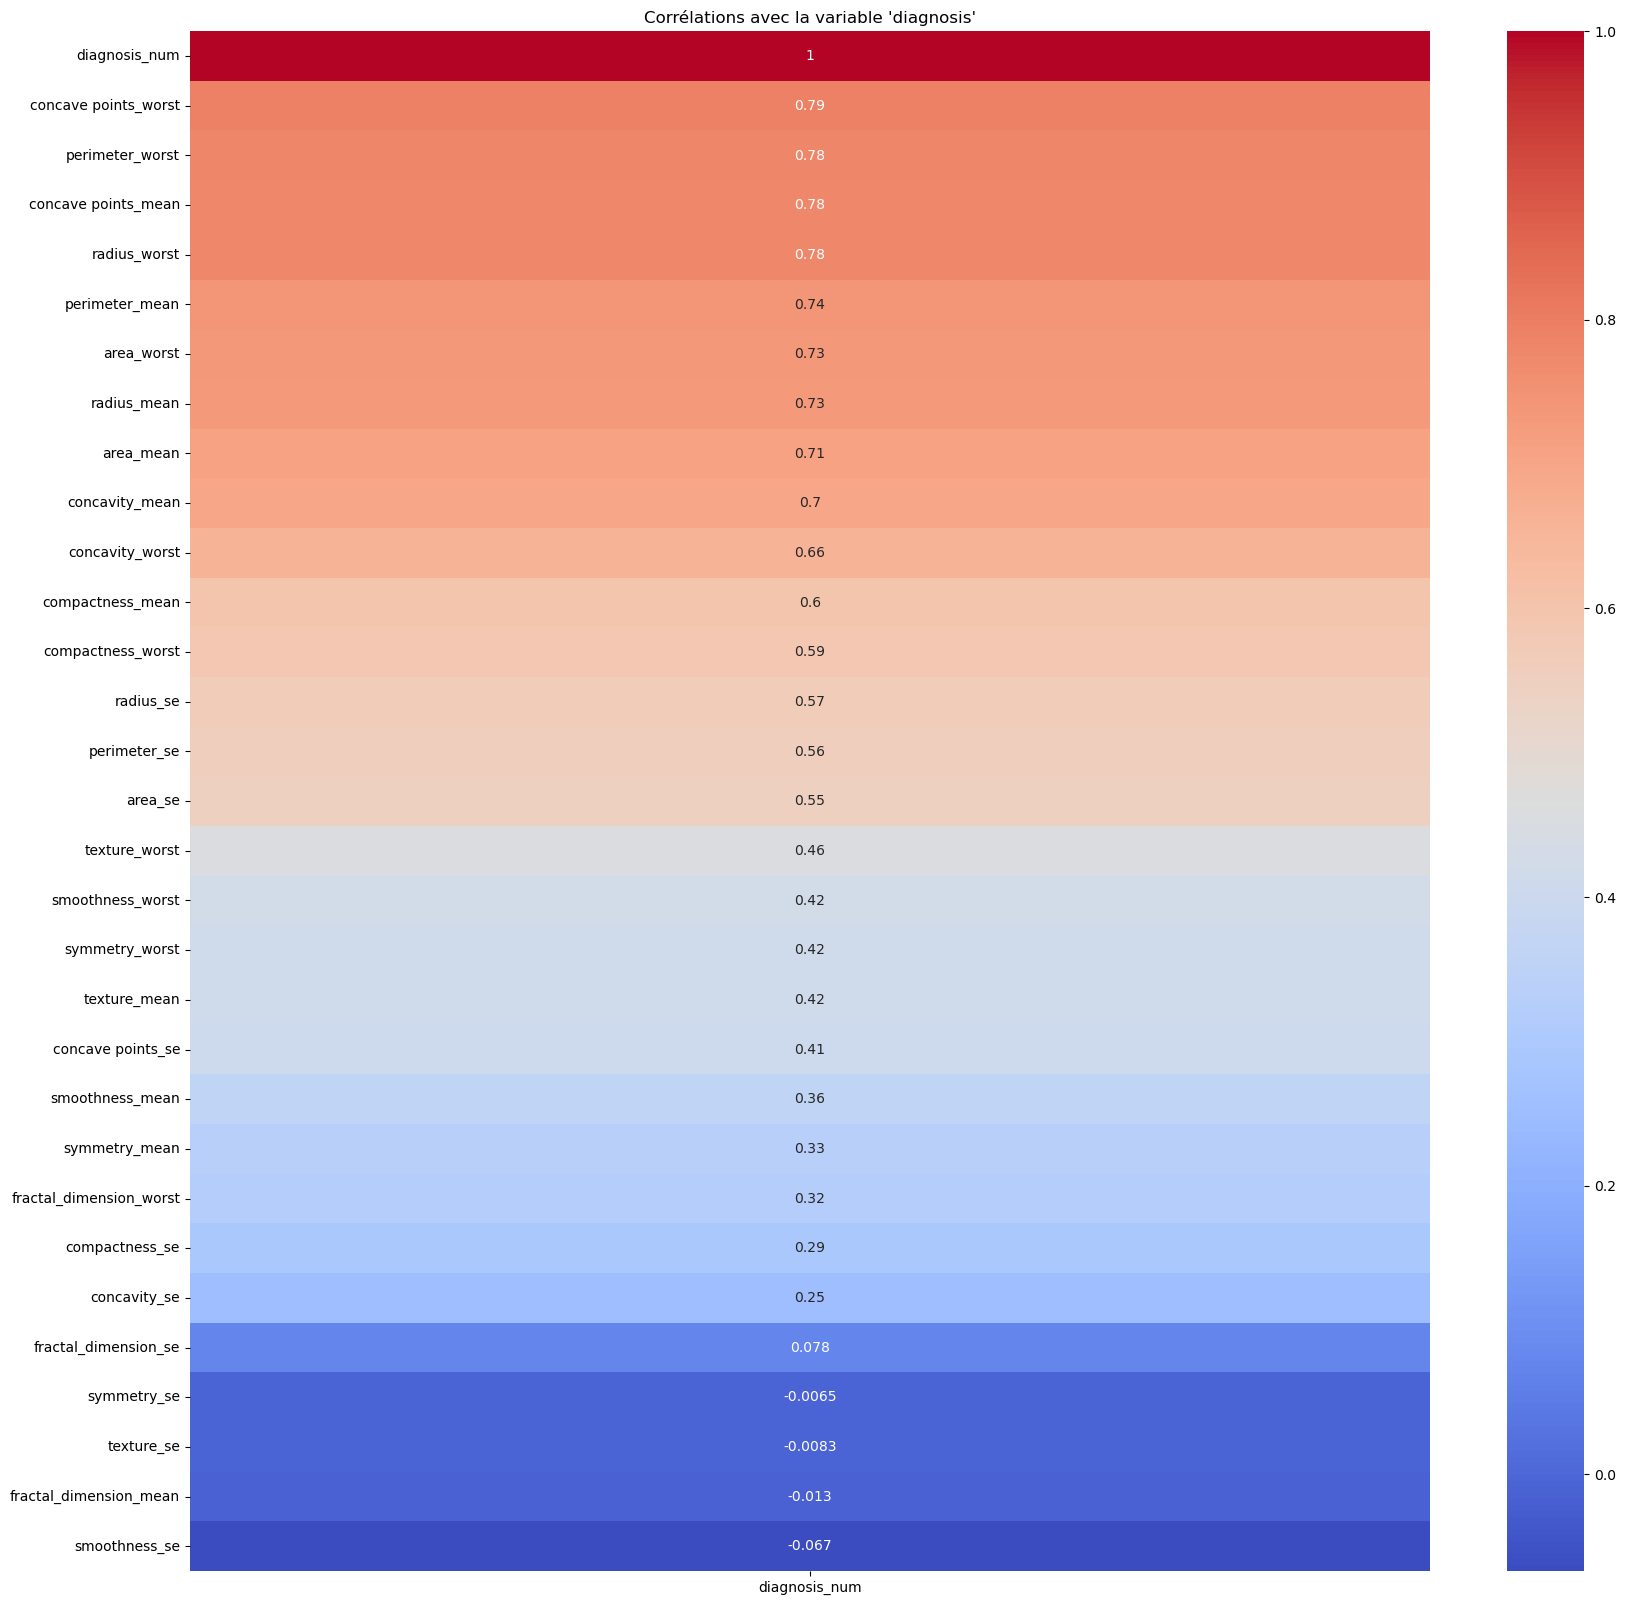

In [43]:
# create a heatmap to check the correlation
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(numeric_only=True)[['diagnosis_num']].sort_values(by='diagnosis_num', ascending=False),
            annot=True, cmap='coolwarm')
plt.title("Corrélations avec la variable 'diagnosis'")
plt.show()

<Axes: xlabel='diagnosis'>

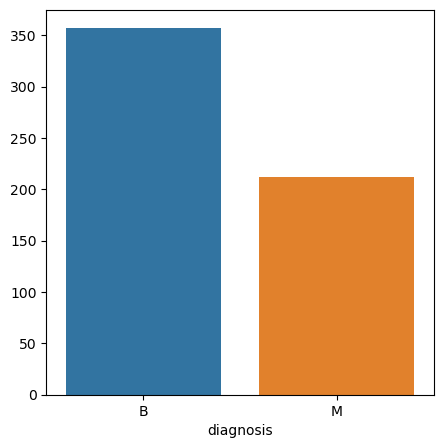

In [24]:
# bar plot for the number of diagnosis
plt.figure(figsize=(5,5))
sns.barplot(x=df['diagnosis'].value_counts().index,y=df['diagnosis'].value_counts().values)


## MODEL

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import LabelEncoder

In [40]:
# Define models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}
# Define scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1']
# Store results
results = {}

In [42]:
##SPLIT THE DATA

In [43]:
from sklearn.model_selection import train_test_split
# Split the data: 80% training, 20% test (untouched)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Testing different model

## Model Evaluation

In [48]:
# 3. Cross-validation on training data
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=5, scoring=scoring)
    results[name] = {
        metric: {
            'mean': scores[f'test_{metric}'].mean(),
            'std': scores[f'test_{metric}'].std()
        }
        for metric in scoring
    }

# 4. Format results into MultiIndex DataFrame
summary_df = pd.DataFrame({
    (model, metric): [scores[metric]['mean'], scores[metric]['std']]
    for model, scores in results.items()
    for metric in scoring
}, index=['Mean', 'Std']).T

summary_df = summary_df.round(3)
print(summary_df)

                          Mean    Std
Decision Tree accuracy   0.916  0.018
              precision  0.883  0.047
              recall     0.900  0.071
              f1         0.888  0.027
Random Forest accuracy   0.956  0.016
              precision  0.958  0.023
              recall     0.923  0.044
              f1         0.939  0.022
XGBoost       accuracy   0.965  0.015
              precision  0.964  0.012
              recall     0.941  0.037
              f1         0.952  0.021


In [39]:
# Format results into a clean MultiIndex DataFrame
summary_df = pd.DataFrame({
    (model, metric): [scores[metric]['mean'], scores[metric]['std']]
    for model, scores in results.items()
    for metric in scoring
}, index=['Mean', 'Std']).T

# Optional: sort by 'accuracy' mean
summary_df = summary_df.sort_values(by=('XGBoost', 'accuracy'), ascending=False) if ('XGBoost', 'accuracy') in summary_df.columns else summary_df

# Round for readability
summary_df = summary_df.round(3)
# Display
print(summary_df)

                          Mean    Std
Decision Tree accuracy   0.917  0.024
              precision  0.879  0.058
              recall     0.911  0.034
              f1         0.892  0.028
Random Forest accuracy   0.956  0.023
              precision  0.953  0.034
              recall     0.930  0.044
              f1         0.940  0.030
XGBoost       accuracy   0.974  0.015
              precision  0.972  0.022
              recall     0.958  0.037
              f1         0.964  0.020


In [51]:
##Using the XGBoost to make prediction
from sklearn.metrics import classification_report
best_model = XGBClassifier(eval_metric='logloss')
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
print("\nClassification Report on Untouched Test Set:")
print(classification_report(y_test, y_pred))


Classification Report on Untouched Test Set:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



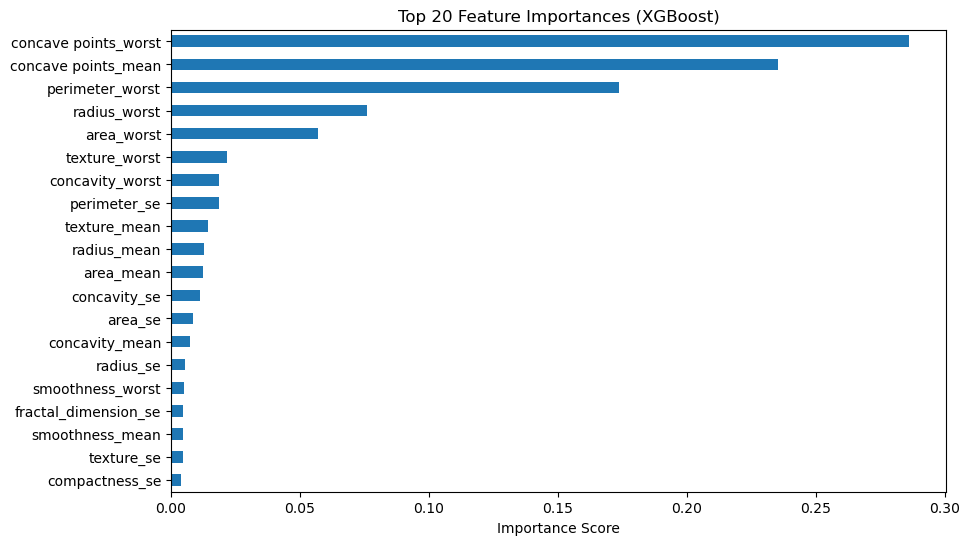

In [55]:
from xgboost import XGBClassifier, plot_importance
# Get and sort feature importances from the already-trained model
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

# Plot top 20 most important features
importances.head(20).plot(kind='barh', figsize=(10, 6))
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (XGBoost)")
plt.xlabel("Importance Score")
plt.show()

##MODEL BASED ON THE MOST IMPORTANT FEATURES

In [56]:
top_k_features = importances.head(10).index.tolist()
X_train_top = X_train[top_k_features]
X_test_top = X_test[top_k_features]

In [57]:
# Retrain model with top features
best_model_top = XGBClassifier(eval_metric='logloss')
best_model_top.fit(X_train_top, y_train)
y_pred_top = best_model_top.predict(X_test_top)

# Evaluate
from sklearn.metrics import classification_report
print("\nClassification Report with Top 10 Features:")
print(classification_report(y_test, y_pred_top))


Classification Report with Top 10 Features:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



##deployment of the model using streamlit 

In [59]:
import joblib
# Get top 10 features
top_features = importances.head(10).index.tolist()
# Save the model and feature names
joblib.dump(best_model_top, 'xgb_top10_model.pkl')
joblib.dump(top_features, 'top10_features.pkl')

['top10_features.pkl']

## Conclusion

From both the models we can see that the accuracy is 93.5% and 97% respectively. But we can see that the recall value for the logistic regression is 97% which is better than the decision tree classifier. So we can say that the logistic regression is better than the decision tree classifier.